Total kalimat: 300

=== Distribusi Jumlah Kata ===
count    300.00
mean      22.07
std       11.11
min        6.00
25%       14.00
50%       19.50
75%       28.00
max       65.00

=== Distribusi Jumlah Karakter ===
count    300.00
mean     127.04
std       67.23
min       33.00
25%       78.75
50%      111.50
75%      157.50
max      387.00


/tmp/ipykernel_1372954/1381900104.py:71: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(n_words, vert=True, patch_artist=True,
/tmp/ipykernel_1372954/1381900104.py:87: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(n_chars, vert=True, patch_artist=True,


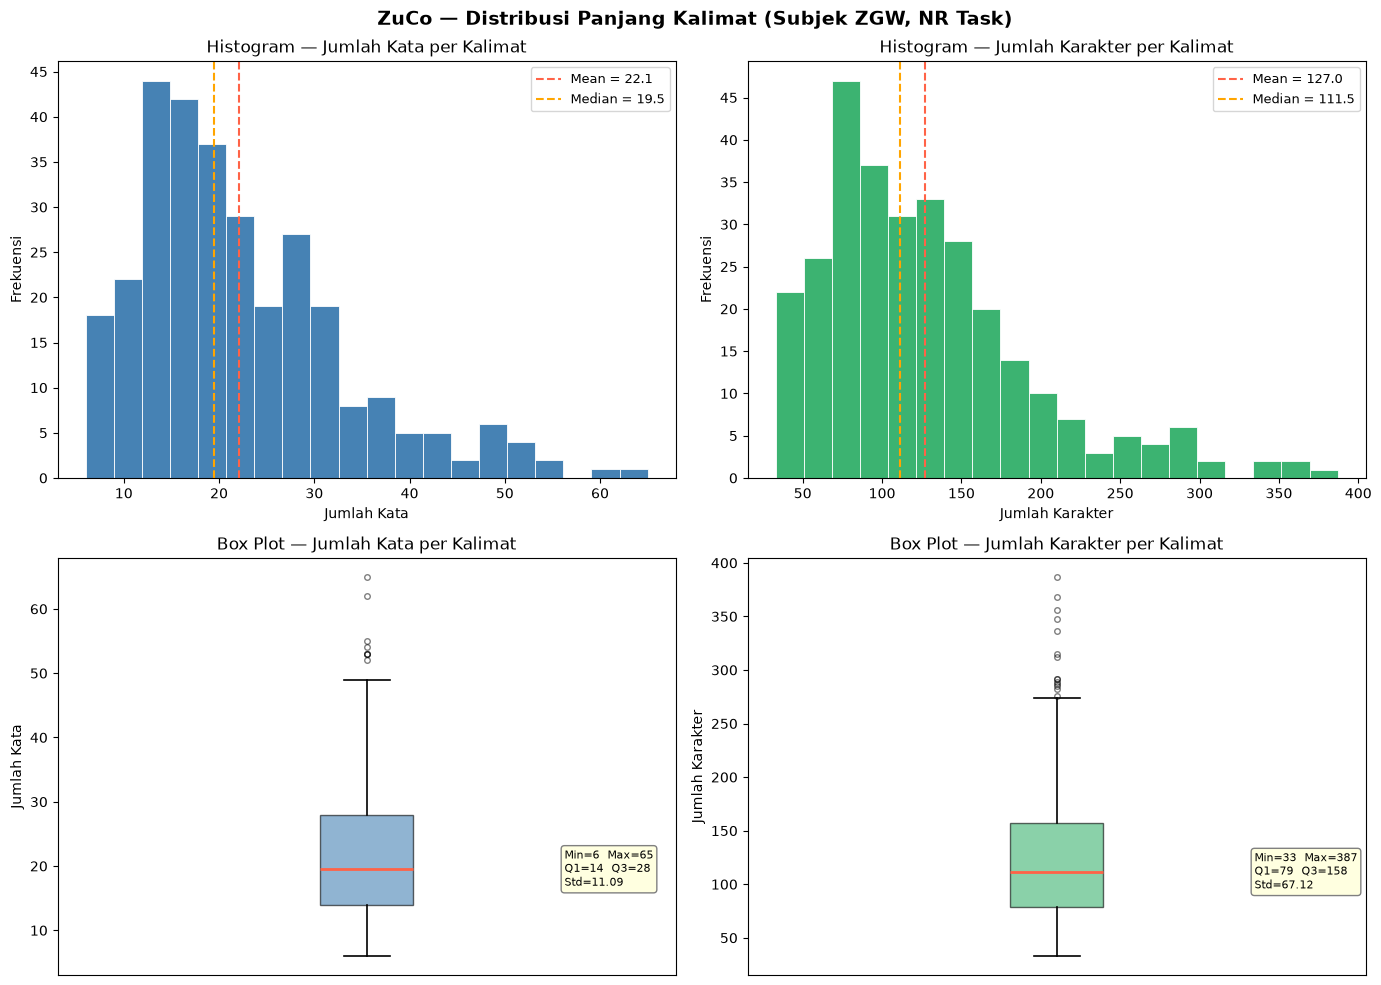

Plot tersimpan di experiments/ZuCo/ZGW_sentence_length_distribution.png


,Persentil (%),Jumlah Kata,Jumlah Karakter
0,0,6.0,33.0
1,10,10.9,58.9
2,25,14.0,78.8
3,50,19.5,111.5
4,75,28.0,157.5
5,90,37.0,214.3
6,95,45.1,273.0
7,100,65.0,387.0


In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.io as sio
from IPython.display import display

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../../../'))
MAT_PATH = os.path.join(PROJECT_ROOT, 'dataset/zuco/v1/NR/resultsZGW_NR.mat')

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[-\u2013\u2014]', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

mat  = sio.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)
data = mat['sentenceData']

sentences = []
for trial in data:
    content = getattr(trial, 'content', None)
    if content is None:
        continue
    s = normalize_text(str(content))
    if s:
        sentences.append(s)

n_words  = [len(s.split()) for s in sentences]
n_chars  = [len(s) for s in sentences]

df = pd.DataFrame({
    'sentence': sentences,
    'word_count': n_words,
    'char_count': n_chars,
})

print(f"Total kalimat: {len(df)}")
print()
print("=== Distribusi Jumlah Kata ===")
print(df['word_count'].describe().round(2).to_string())
print()
print("=== Distribusi Jumlah Karakter ===")
print(df['char_count'].describe().round(2).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ZuCo — Distribusi Panjang Kalimat (Subjek ZGW, NR Task)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(n_words, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
ax.axvline(np.mean(n_words), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(n_words):.1f}')
ax.axvline(np.median(n_words), color='orange', linestyle='--', linewidth=1.5, label=f'Median = {np.median(n_words):.1f}')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.set_title('Histogram — Jumlah Kata per Kalimat')
ax.legend(fontsize=9)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax = axes[0, 1]
ax.hist(n_chars, bins=20, color='mediumseagreen', edgecolor='white', linewidth=0.6)
ax.axvline(np.mean(n_chars), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(n_chars):.1f}')
ax.axvline(np.median(n_chars), color='orange', linestyle='--', linewidth=1.5, label=f'Median = {np.median(n_chars):.1f}')
ax.set_xlabel('Jumlah Karakter')
ax.set_ylabel('Frekuensi')
ax.set_title('Histogram — Jumlah Karakter per Kalimat')
ax.legend(fontsize=9)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax = axes[1, 0]
bp = ax.boxplot(n_words, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='tomato', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=4, alpha=0.5))
ax.set_ylabel('Jumlah Kata')
ax.set_title('Box Plot — Jumlah Kata per Kalimat')
ax.set_xticks([])
stats_text = (f'Min={min(n_words)}  Max={max(n_words)}\n'
              f'Q1={np.percentile(n_words,25):.0f}  Q3={np.percentile(n_words,75):.0f}\n'
              f'Std={np.std(n_words):.2f}')
ax.text(1.32, np.median(n_words), stats_text, va='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

ax = axes[1, 1]
ax.boxplot(n_chars, vert=True, patch_artist=True,
           boxprops=dict(facecolor='mediumseagreen', alpha=0.6),
           medianprops=dict(color='tomato', linewidth=2),
           whiskerprops=dict(linewidth=1.2),
           capprops=dict(linewidth=1.2),
           flierprops=dict(marker='o', markersize=4, alpha=0.5))
ax.set_ylabel('Jumlah Karakter')
ax.set_title('Box Plot — Jumlah Karakter per Kalimat')
ax.set_xticks([])
stats_text = (f'Min={min(n_chars)}  Max={max(n_chars)}\n'
              f'Q1={np.percentile(n_chars,25):.0f}  Q3={np.percentile(n_chars,75):.0f}\n'
              f'Std={np.std(n_chars):.2f}')
ax.text(1.32, np.median(n_chars), stats_text, va='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'experiments/ZuCo/ZGW_sentence_length_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan di experiments/ZuCo/ZGW_sentence_length_distribution.png")

percentiles = [0, 10, 25, 50, 75, 90, 95, 100]
rows = []
for p in percentiles:
    rows.append({
        'Persentil (%)': p,
        'Jumlah Kata':    round(np.percentile(n_words, p), 1),
        'Jumlah Karakter': round(np.percentile(n_chars, p), 1),
    })
display(pd.DataFrame(rows))
